In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.datasets import make_circles, make_moons, make_classification
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

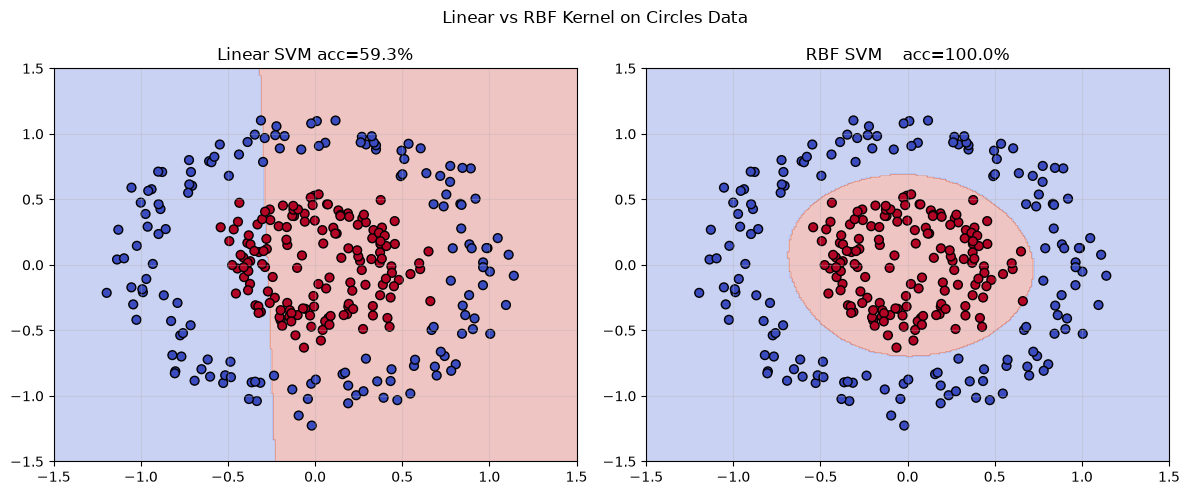

In [2]:
# Cell 2 — Version 1: why kernels? non-linearly separable data
np.random.seed(42)
X, y = make_circles(n_samples=300, noise=0.1, factor=0.4, random_state=42)

# linear SVM fails here
linear_svm = SVC(kernel='linear', C=1)
linear_svm.fit(X, y)
lin_acc = accuracy_score(y, linear_svm.predict(X))

# RBF kernel works
rbf_svm = SVC(kernel='rbf', C=1, gamma='scale')
rbf_svm.fit(X, y)
rbf_acc = accuracy_score(y, rbf_svm.predict(X))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, model, title in zip(axes,
                              [linear_svm, rbf_svm],
                              [f'Linear SVM acc={lin_acc*100:.1f}%',
                               f'RBF SVM    acc={rbf_acc*100:.1f}%']):
    xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 300),
                         np.linspace(-1.5, 1.5, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k', s=40)
    ax.set_title(title); ax.grid(True, alpha=0.3)

plt.suptitle('Linear vs RBF Kernel on Circles Data')
plt.tight_layout(); plt.show()

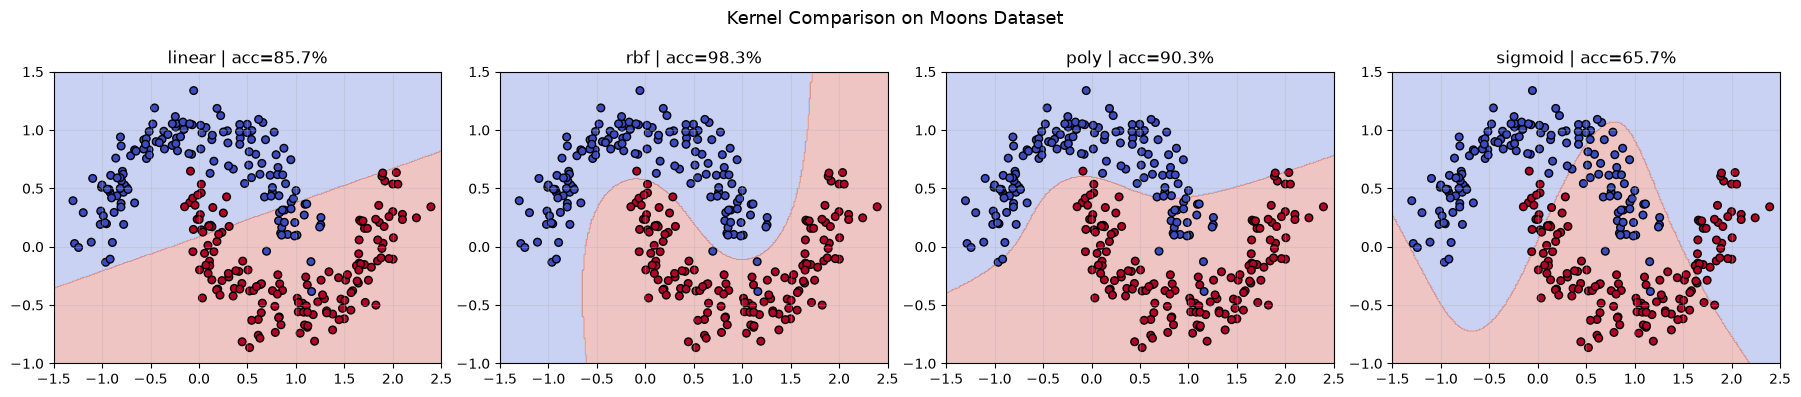

In [3]:
# Cell 3 — Version 2: kernel types compared side by side
np.random.seed(0)
X, y = make_moons(n_samples=300, noise=0.15, random_state=0)

kernels = ['linear', 'rbf', 'poly', 'sigmoid']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, kernel in zip(axes, kernels):
    model = SVC(kernel=kernel, C=1, gamma='scale', degree=3)
    model.fit(X, y)
    acc = accuracy_score(y, model.predict(X))

    xx, yy = np.meshgrid(np.linspace(-1.5, 2.5, 300),
                         np.linspace(-1, 1.5, 300))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k', s=30)
    ax.set_title(f'{kernel} | acc={acc*100:.1f}%')
    ax.grid(True, alpha=0.3)

plt.suptitle('Kernel Comparison on Moons Dataset', fontsize=13)
plt.tight_layout(); plt.show()

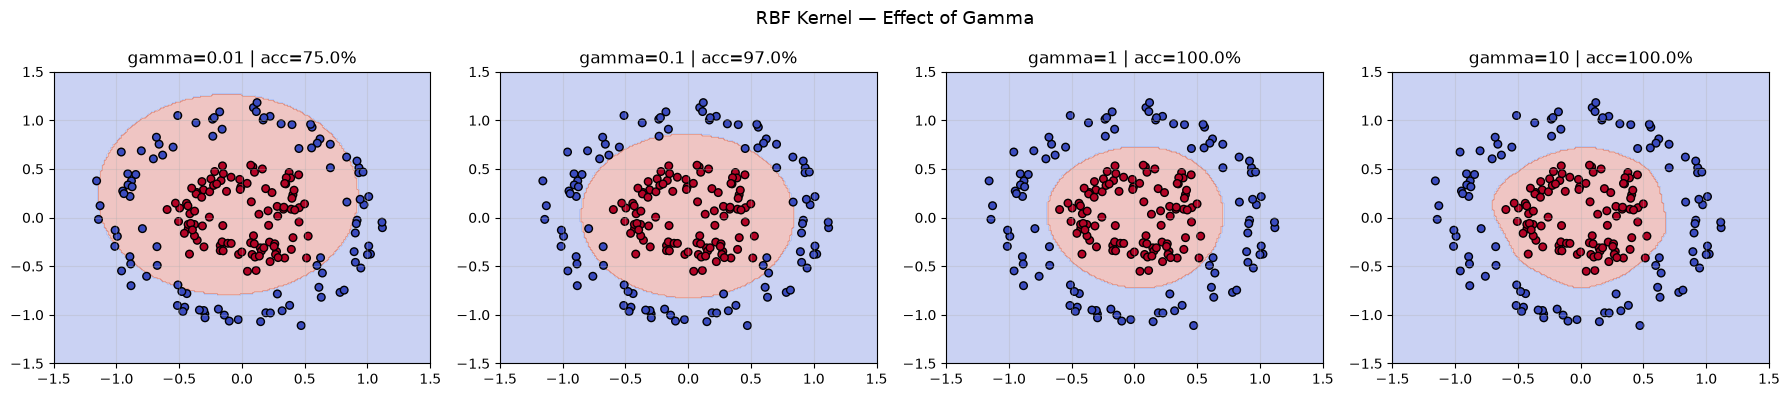

Low gamma → underfits. High gamma → overfits. ✅


In [4]:
# Cell 4 — Version 3: RBF gamma effect
# gamma = how far influence of a single training point reaches
# High gamma → tight fit (overfit), Low gamma → smooth boundary

np.random.seed(42)
X, y = make_circles(n_samples=200, noise=0.1, factor=0.4, random_state=42)

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, gamma in zip(axes, [0.01, 0.1, 1, 10]):
    model = SVC(kernel='rbf', C=1, gamma=gamma)
    model.fit(X, y)
    acc = accuracy_score(y, model.predict(X))

    xx, yy = np.meshgrid(np.linspace(-1.5, 1.5, 200),
                         np.linspace(-1.5, 1.5, 200))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    ax.scatter(X[:,0], X[:,1], c=y, cmap='coolwarm', edgecolors='k', s=30)
    ax.set_title(f'gamma={gamma} | acc={acc*100:.1f}%')
    ax.grid(True, alpha=0.3)

plt.suptitle('RBF Kernel — Effect of Gamma', fontsize=13)
plt.tight_layout(); plt.show()
print("Low gamma → underfits. High gamma → overfits. ✅")

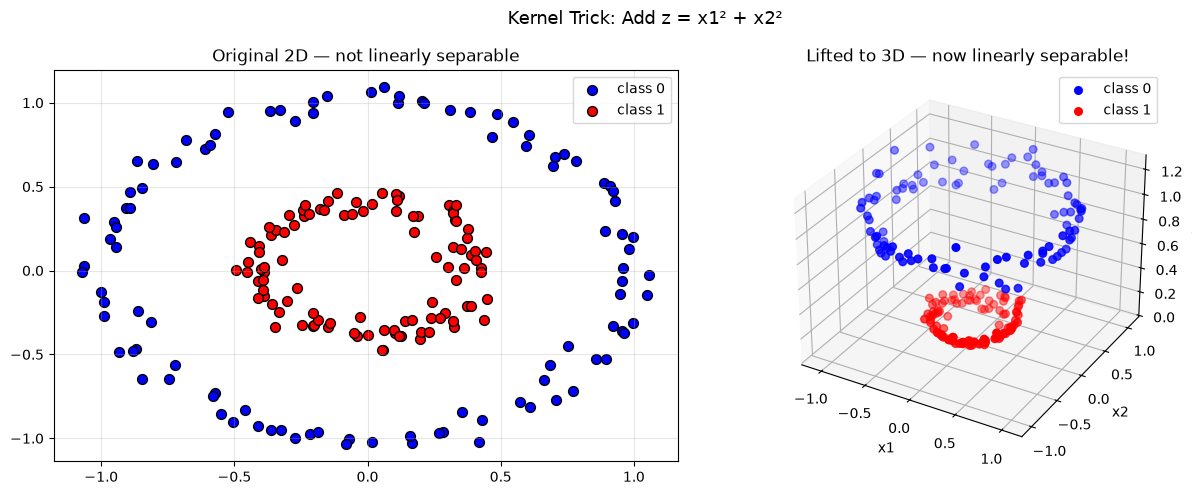

In 3D you can now cut with a flat plane → that's what RBF kernel does internally ✅


In [5]:
# Cell 5 — Version 4: kernel trick intuition — lift to 3D
# For circles data: add feature z = x1² + x2²
# In 3D the classes become linearly separable!

np.random.seed(42)
X, y = make_circles(n_samples=200, noise=0.05, factor=0.4, random_state=42)

# original 2D
fig = plt.figure(figsize=(13, 5))

ax1 = fig.add_subplot(121)
ax1.scatter(X[y==0,0], X[y==0,1], c='blue', s=50, label='class 0', edgecolors='k')
ax1.scatter(X[y==1,0], X[y==1,1], c='red',  s=50, label='class 1', edgecolors='k')
ax1.set_title('Original 2D — not linearly separable')
ax1.legend(); ax1.grid(True, alpha=0.3)

# lifted to 3D
z = X[:,0]**2 + X[:,1]**2   # kernel feature
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(X[y==0,0], X[y==0,1], z[y==0], c='blue', s=30, label='class 0')
ax2.scatter(X[y==1,0], X[y==1,1], z[y==1], c='red',  s=30, label='class 1')
ax2.set_xlabel('x1'); ax2.set_ylabel('x2'); ax2.set_zlabel('z = x1²+x2²')
ax2.set_title('Lifted to 3D — now linearly separable!')
ax2.legend()

plt.suptitle('Kernel Trick: Add z = x1² + x2²', fontsize=13)
plt.tight_layout(); plt.show()
print("In 3D you can now cut with a flat plane → that's what RBF kernel does internally ✅")